In [84]:
# ============================================
# CELL 1: IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import sqlite3
import os
import warnings

warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [85]:
import pandas as pd

# Load the datasets
customers = pd.read_csv("db_customer.csv")
subscriptions = pd.read_csv("db_subscription.csv")
support = pd.read_csv("db_support.csv")

# Check the data
print("Customers:", customers.shape)
print("Subscriptions:", subscriptions.shape)
print("Support:", support.shape)

Customers: (10000, 8)
Subscriptions: (10000, 11)
Support: (19584, 6)


In [86]:
# ============================================
# CELL 3: CHECK COLUMNS
# ============================================

print("CUSTOMER COLUMNS")
print(customers.columns.tolist())

print("\nSUBSCRIPTION COLUMNS")
print(subscriptions.columns.tolist())

print("\nSUPPORT COLUMNS")
print(support.columns.tolist())

CUSTOMER COLUMNS
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

SUBSCRIPTION COLUMNS
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

SUPPORT COLUMNS
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [87]:
# ============================================
# CELL 4: FIRST LOOK
# ============================================

display(customers.head())
display(subscriptions.head())
display(support.head())

,customerid,name,country,state,gender,dob,interests,pincode
0,CUST100000,Aditi Bose,India,Rajasthan,Female,2008-06-29,Sports,3423743
1,CUST100001,Ayush Bose,India,Delhi,Prefer not to say,2000-09-04,Regional Content,1109467
2,CUST100002,Nikhil Das,India,Uttar Pradesh,Male,2000-11-29,News,2086513
3,CUST100003,Meera Verma,India,Gujarat,Male,1997-11-19,Movies & Series,3608834
4,CUST100004,Rohan Rao,India,Maharashtra,Female,1988-10-28,News,4008603


,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,CUST100000,2022-07-06,OTT Video,2022-10-04,Standard,Quarterly,NaN,NaN,362.0,1525.76,29
1,CUST100001,2023-09-10,Family Bundle,2023-10-10,Premium,Monthly,2024-10-30,Not using service,722.0,1443.23,44
2,CUST100002,2023-12-20,OTT Video,2024-03-19,Basic,Quarterly,NaN,NaN,194.0,687.16,33
3,CUST100003,2023-12-03,OTT Video,2024-12-02,Basic,Annual,NaN,NaN,218.0,759.73,35
4,CUST100004,2025-07-11,Family Bundle,2025-10-09,Standard,Quarterly,NaN,NaN,473.0,1151.35,15


,customerid,complaint_date,escalations,csat_score,col_1,comment
0,CUST100000,2025-08-18,0,2.8,Price too high,Monthly price feels expensive
1,CUST100000,2024-02-26,0,2.5,Payment issues,Payment failed during renewal
2,CUST100001,2023-09-16,0,4.6,Not using service,Too busy to use the service
3,CUST100001,2023-10-18,0,4.5,Not using service,Usage dropped over the last few months
4,CUST100001,2024-06-24,0,3.4,Not using service,Not watching frequently


In [88]:
 # ============================================
# CELL 4: FIRST LOOK
# ============================================

display(customers.head())
display(subscriptions.head())
display(support.head())

,customerid,name,country,state,gender,dob,interests,pincode
0,CUST100000,Aditi Bose,India,Rajasthan,Female,2008-06-29,Sports,3423743
1,CUST100001,Ayush Bose,India,Delhi,Prefer not to say,2000-09-04,Regional Content,1109467
2,CUST100002,Nikhil Das,India,Uttar Pradesh,Male,2000-11-29,News,2086513
3,CUST100003,Meera Verma,India,Gujarat,Male,1997-11-19,Movies & Series,3608834
4,CUST100004,Rohan Rao,India,Maharashtra,Female,1988-10-28,News,4008603


,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,CUST100000,2022-07-06,OTT Video,2022-10-04,Standard,Quarterly,NaN,NaN,362.0,1525.76,29
1,CUST100001,2023-09-10,Family Bundle,2023-10-10,Premium,Monthly,2024-10-30,Not using service,722.0,1443.23,44
2,CUST100002,2023-12-20,OTT Video,2024-03-19,Basic,Quarterly,NaN,NaN,194.0,687.16,33
3,CUST100003,2023-12-03,OTT Video,2024-12-02,Basic,Annual,NaN,NaN,218.0,759.73,35
4,CUST100004,2025-07-11,Family Bundle,2025-10-09,Standard,Quarterly,NaN,NaN,473.0,1151.35,15


,customerid,complaint_date,escalations,csat_score,col_1,comment
0,CUST100000,2025-08-18,0,2.8,Price too high,Monthly price feels expensive
1,CUST100000,2024-02-26,0,2.5,Payment issues,Payment failed during renewal
2,CUST100001,2023-09-16,0,4.6,Not using service,Too busy to use the service
3,CUST100001,2023-10-18,0,4.5,Not using service,Usage dropped over the last few months
4,CUST100001,2024-06-24,0,3.4,Not using service,Not watching frequently


In [89]:
print("Customer Information")
customers.info()

print("\nSubscription Information")
subscriptions.info()

print("\nSupport Information")
support.info()

Customer Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  10000 non-null  object
 1   name        10000 non-null  object
 2   country     10000 non-null  object
 3   state       10000 non-null  object
 4   gender      10000 non-null  object
 5   dob         10000 non-null  object
 6   interests   10000 non-null  object
 7   pincode     10000 non-null  int64 
dtypes: int64(1), object(7)
memory usage: 625.1+ KB

Subscription Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               10000 non-null  object 
 1   subscription_start_date  10000 non-null  object 
 2   subscription_type        10000 non-null  object 
 3   renewal_dat

In [90]:
# ============================================
# CELL 5: MISSING VALUES
# ============================================

print("CUSTOMERS - Missing Values")
print(customers.isnull().sum())

print("\nSUBSCRIPTIONS - Missing Values")
print(subscriptions.isnull().sum())

print("\nSUPPORT - Missing Values")
print(support.isnull().sum())

CUSTOMERS - Missing Values
customerid    0
name          0
country       0
state         0
gender        0
dob           0
interests     0
pincode       0
dtype: int64

SUBSCRIPTIONS - Missing Values
customerid                    0
subscription_start_date       0
subscription_type             0
renewal_date                  0
plan_type                     0
contract_type                 0
cancellation_date          7500
cancellation_reason        7500
monthly_charges               0
cltv                          0
churn_score                   0
dtype: int64

SUPPORT - Missing Values
customerid        0
complaint_date    0
escalations       0
csat_score        0
col_1             0
comment           0
dtype: int64


In [91]:
# Missing percentage

def missing_report(df):
    result = pd.DataFrame({
        "Missing_Count": df.isnull().sum(),
        "Missing_Percentage": df.isnull().mean() * 100
    })
    
    return result.sort_values(
        "Missing_Percentage",
        ascending=False
    )

display(missing_report(customers))
display(missing_report(subscriptions))
display(missing_report(support))

,Missing_Count,Missing_Percentage
customerid,0,0.0
name,0,0.0
country,0,0.0
state,0,0.0
gender,0,0.0
dob,0,0.0
interests,0,0.0
pincode,0,0.0


,Missing_Count,Missing_Percentage
cancellation_date,7500,75.0
cancellation_reason,7500,75.0
customerid,0,0.0
subscription_type,0,0.0
subscription_start_date,0,0.0
plan_type,0,0.0
renewal_date,0,0.0
contract_type,0,0.0
monthly_charges,0,0.0
cltv,0,0.0


,Missing_Count,Missing_Percentage
customerid,0,0.0
complaint_date,0,0.0
escalations,0,0.0
csat_score,0,0.0
col_1,0,0.0
comment,0,0.0


In [92]:
# ============================================
# CELL 6: DUPLICATES
# ============================================

print("Customer duplicates:", customers.duplicated().sum())
print("Subscription duplicates:", subscriptions.duplicated().sum())
print("Support duplicates:", support.duplicated().sum())

Customer duplicates: 0
Subscription duplicates: 0
Support duplicates: 0


In [93]:
print("Unique customers:", customers["customerid"].nunique())
print("Subscription customer IDs:", subscriptions["customerid"].nunique())
print("Support customer IDs:", support["customerid"].nunique())

Unique customers: 10000
Subscription customer IDs: 10000
Support customer IDs: 8550


In [94]:
# ============================================
# CELL 7: CLEAN COLUMN NAMES
# ============================================

customers.columns = (
    customers.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

subscriptions.columns = (
    subscriptions.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

support.columns = (
    support.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(customers.columns.tolist())
print(subscriptions.columns.tolist())
print(support.columns.tolist())

['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [95]:
# ============================================
# CELL 8: DATE CONVERSION
# ============================================

customer_date_columns = [
    "dob"
]

subscription_date_columns = [
    "subscription_start_date",
    "renewal_date",
    "cancellation_date"
]

support_date_columns = [
    "complaint_date"
]

for col in customer_date_columns:
    customers[col] = pd.to_datetime(
        customers[col],
        errors="coerce"
    )

for col in subscription_date_columns:
    subscriptions[col] = pd.to_datetime(
        subscriptions[col],
        errors="coerce"
    )

for col in support_date_columns:
    support[col] = pd.to_datetime(
        support[col],
        errors="coerce"
    )

print("Date conversion completed.")

Date conversion completed.


In [96]:
print(customers["dob"].dtype)

print(subscriptions[
    [
        "subscription_start_date",
        "renewal_date",
        "cancellation_date"
    ]
].dtypes)

print(support["complaint_date"].dtype)

datetime64[ns]
subscription_start_date    datetime64[ns]
renewal_date               datetime64[ns]
cancellation_date          datetime64[ns]
dtype: object
datetime64[ns]


In [97]:
# ============================================
# CELL 9: CHURN FLAG
# ============================================

subscriptions["churn_flag"] = (
    subscriptions["cancellation_date"]
    .notna()
    .astype(int)
)

subscriptions["churn_status"] = np.where(
    subscriptions["churn_flag"] == 1,
    "Churned",
    "Active"
)

print(
    subscriptions["churn_status"].value_counts()
)

churn_status
Active     7500
Churned    2500
Name: count, dtype: int64


In [98]:
churn_rate = subscriptions["churn_flag"].mean() * 100

print(f"Churn Rate: {churn_rate:.2f}%")
print(f"Retention Rate: {100 - churn_rate:.2f}%")

Churn Rate: 25.00%
Retention Rate: 75.00%


In [99]:
# ============================================
# CELL 10: CATEGORICAL VALUES
# ============================================

print("Subscription Types")
print(subscriptions["subscription_type"].value_counts())

print("\nPlan Types")
print(subscriptions["plan_type"].value_counts())

print("\nContract Types")
print(subscriptions["contract_type"].value_counts())

print("\nCancellation Reasons")
print(
    subscriptions["cancellation_reason"]
    .value_counts(dropna=False)
)

Subscription Types
subscription_type
OTT Video            6795
OTT Video + Music    1781
Family Bundle        1424
Name: count, dtype: int64

Plan Types
plan_type
Basic       4304
Standard    3859
Premium     1837
Name: count, dtype: int64

Contract Types
contract_type
Monthly      5552
Quarterly    2378
Annual       2070
Name: count, dtype: int64

Cancellation Reasons
cancellation_reason
NaN                        7500
Price too high              624
Content dissatisfaction     398
Not using service           343
Competitor switch           324
Technical issues            263
Poor customer support       229
Payment issues              162
Temporary pause             157
Name: count, dtype: int64


In [100]:
# ============================================
# CELL 11: SUPPORT AGGREGATION
# ============================================

# Make sure numeric columns are actually numeric
support["escalations"] = pd.to_numeric(
    support["escalations"],
    errors="coerce"
)

support["csat_score"] = pd.to_numeric(
    support["csat_score"],
    errors="coerce"
)

# Aggregate support information customer-wise
support_summary = (
    support
    .groupby("customerid")
    .agg(
        total_complaints=("customerid", "count"),
        total_escalations=("escalations", "sum"),
        avg_csat=("csat_score", "mean")
    )
    .reset_index()
)

print("Support summary created successfully.")

print("Shape:", support_summary.shape)

display(support_summary.head())

Support summary created successfully.
Shape: (8550, 4)


,customerid,total_complaints,total_escalations,avg_csat
0,CUST100000,2,0,2.650000
1,CUST100001,3,0,4.166667
2,CUST100005,5,1,3.620000
3,CUST100006,4,1,3.375000
4,CUST100007,2,1,3.050000


In [101]:
# ============================================
# CELL 12: MERGE DATASETS
# ============================================

df = customers.merge(
    subscriptions,
    on="customerid",
    how="left"
)

df = df.merge(
    support_summary,
    on="customerid",
    how="left"
)

print("Final dataset shape:", df.shape)

print("Unique customers:", df["customerid"].nunique())

display(df.head())

Final dataset shape: (10000, 23)
Unique customers: 10000


,customerid,name,country,state,gender,dob,interests,pincode,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,churn_status,total_complaints,total_escalations,avg_csat
0,CUST100000,Aditi Bose,India,Rajasthan,Female,2008-06-29,Sports,3423743,2022-07-06,OTT Video,2022-10-04,Standard,Quarterly,NaT,NaN,362.0,1525.76,29,0,Active,2.0,0.0,2.650000
1,CUST100001,Ayush Bose,India,Delhi,Prefer not to say,2000-09-04,Regional Content,1109467,2023-09-10,Family Bundle,2023-10-10,Premium,Monthly,2024-10-30,Not using service,722.0,1443.23,44,1,Churned,3.0,0.0,4.166667
2,CUST100002,Nikhil Das,India,Uttar Pradesh,Male,2000-11-29,News,2086513,2023-12-20,OTT Video,2024-03-19,Basic,Quarterly,NaT,NaN,194.0,687.16,33,0,Active,NaN,NaN,NaN
3,CUST100003,Meera Verma,India,Gujarat,Male,1997-11-19,Movies & Series,3608834,2023-12-03,OTT Video,2024-12-02,Basic,Annual,NaT,NaN,218.0,759.73,35,0,Active,NaN,NaN,NaN
4,CUST100004,Rohan Rao,India,Maharashtra,Female,1988-10-28,News,4008603,2025-07-11,Family Bundle,2025-10-09,Standard,Quarterly,NaT,NaN,473.0,1151.35,15,0,Active,NaN,NaN,NaN


In [102]:
# ============================================
# SUPPORT DATA QUALITY CHECK
# ============================================

print("Support data types:")
print(support.dtypes)

print("\nMissing values:")
print(support.isnull().sum())

print("\nUnique escalation values:")
print(support["escalations"].unique())

print("\nUnique CSAT values:")
print(support["csat_score"].unique())

Support data types:
customerid                object
complaint_date    datetime64[ns]
escalations                int64
csat_score               float64
col_1                     object
comment                   object
dtype: object

Missing values:
customerid        0
complaint_date    0
escalations       0
csat_score        0
col_1             0
comment           0
dtype: int64

Unique escalation values:
[0 1]

Unique CSAT values:
[2.8 2.5 4.6 4.5 3.4 2.3 4.1 4.7 3.6 3.8 3.3 3.  2.6 3.5 5.  3.9 3.2 2.9
 4.  4.2 4.4 4.3 2.7 3.7 3.1 2.4 2.2 1.9 1.5 4.9 4.8 2.1 1.7 2.  1.6 1.8
 1.1 1.3 1.2 1.  1.4]


In [103]:
# ============================================
# CELL 13: SUPPORT MISSING VALUES
# ============================================

# Customers with no support records
# are treated as having zero complaints
# and zero escalations.

df["total_complaints"] = (
    df["total_complaints"]
    .fillna(0)
)

df["total_escalations"] = (
    df["total_escalations"]
    .fillna(0)
)

# Fill missing CSAT with the overall median
df["avg_csat"] = (
    df["avg_csat"]
    .fillna(df["avg_csat"].median())
)

print("Support missing values handled successfully.")

print("\nMissing values after treatment:")
print(
    df[
        [
            "total_complaints",
            "total_escalations",
            "avg_csat"
        ]
    ].isnull().sum()
)

Support missing values handled successfully.

Missing values after treatment:
total_complaints     0
total_escalations    0
avg_csat             0
dtype: int64


In [104]:
# ============================================
# CHECK MASTER DATASET
# ============================================

print("Dataset shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nSupport-related columns:")
print([
    col for col in df.columns
    if col in [
        "total_complaints",
        "total_escalations",
        "avg_csat"
    ]
])

Dataset shape:
(10000, 23)

Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score', 'churn_flag', 'churn_status', 'total_complaints', 'total_escalations', 'avg_csat']

Support-related columns:
['total_complaints', 'total_escalations', 'avg_csat']


In [105]:
display(
    df[
        [
            "customerid",
            "total_complaints",
            "total_escalations",
            "avg_csat"
        ]
    ].head(10)
)

,customerid,total_complaints,total_escalations,avg_csat
0,CUST100000,2.0,0.0,2.650000
1,CUST100001,3.0,0.0,4.166667
2,CUST100002,0.0,0.0,3.500000
3,CUST100003,0.0,0.0,3.500000
4,CUST100004,0.0,0.0,3.500000
5,CUST100005,5.0,1.0,3.620000
6,CUST100006,4.0,1.0,3.375000
7,CUST100007,2.0,1.0,3.050000
8,CUST100008,1.0,1.0,3.400000
9,CUST100009,2.0,0.0,4.450000


In [106]:
# ============================================
# CELL 14: FEATURE ENGINEERING
# ============================================

# Analysis date
all_dates = pd.concat([
    subscriptions["subscription_start_date"],
    subscriptions["renewal_date"],
    subscriptions["cancellation_date"],
    support["complaint_date"]
])

analysis_date = all_dates.max()

print("Analysis Date:", analysis_date)

Analysis Date: 2027-07-30 00:00:00


In [107]:
df["age"] = (
    (analysis_date - df["dob"])
    .dt.days / 365.25
)

df["age"] = df["age"].round(1)

In [108]:
df["tenure_end_date"] = df["cancellation_date"].fillna(
    analysis_date
)

df["tenure_days"] = (
    df["tenure_end_date"] -
    df["subscription_start_date"]
).dt.days

df["tenure_months"] = (
    df["tenure_days"] / 30.44
).round(1)

df["tenure_years"] = (
    df["tenure_days"] / 365.25
).round(2)

In [109]:
# ============================================
# CELL 15: REVENUE FEATURES
# ============================================

df["annual_revenue"] = (
    df["monthly_charges"] * 12
)

df["revenue_lost"] = np.where(
    df["churn_flag"] == 1,
    df["monthly_charges"],
    0
)

df["cltv_lost"] = np.where(
    df["churn_flag"] == 1,
    df["cltv"],
    0
)

df["escalation_flag"] = (
    df["total_escalations"] > 0
).astype(int)

df["complaint_flag"] = (
    df["total_complaints"] > 0
).astype(int)

In [110]:
# ============================================
# CELL 16: RISK CATEGORIES
# ============================================

def risk_category(score):
    
    if score >= 70:
        return "High Risk"
    
    elif score >= 40:
        return "Medium Risk"
    
    else:
        return "Low Risk"


df["risk_category"] = (
    df["churn_score"]
    .apply(risk_category)
)

print(
    df["risk_category"]
    .value_counts()
)

risk_category
Medium Risk    4518
Low Risk       3794
High Risk      1688
Name: count, dtype: int64


In [111]:
# ============================================
# CELL 17: FINAL DATA QUALITY
# ============================================

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nMissing values:")
display(
    df.isnull().sum()
    .sort_values(ascending=False)
    .head(20)
)

Rows: 10000
Columns: 34

Duplicate rows:
0

Missing values:


cancellation_date          7500
cancellation_reason        7500
name                          0
customerid                    0
country                       0
state                         0
interests                     0
pincode                       0
gender                        0
dob                           0
subscription_type             0
subscription_start_date       0
plan_type                     0
renewal_date                  0
contract_type                 0
monthly_charges               0
cltv                          0
churn_score                   0
churn_flag                    0
churn_status                  0
dtype: int64

In [112]:
# ============================================
# CELL 18: BUSINESS KPIs
# ============================================

total_customers = len(df)

churned_customers = df["churn_flag"].sum()

active_customers = (
    total_customers -
    churned_customers
)

churn_rate = (
    churned_customers /
    total_customers
) * 100

retention_rate = 100 - churn_rate

arpu = (
    df.loc[
        df["churn_flag"] == 0,
        "monthly_charges"
    ].sum()
    /
    active_customers
)

avg_tenure = df["tenure_days"].mean()

total_revenue = (
    df["monthly_charges"].sum()
)

revenue_loss = (
    df.loc[
        df["churn_flag"] == 1,
        "monthly_charges"
    ].sum()
)

cltv_lost = (
    df.loc[
        df["churn_flag"] == 1,
        "cltv"
    ].sum()
)

revenue_at_risk = (
    df.loc[
        (df["churn_score"] > 70) &
        (df["churn_flag"] == 0),
        "monthly_charges"
    ].sum()
)

escalation_rate = (
    df["escalation_flag"].mean() * 100
)

avg_complaints = (
    df["total_complaints"].mean()
)

kpis = {
    "Total Customers": total_customers,
    "Active Customers": active_customers,
    "Churned Customers": churned_customers,
    "Churn Rate (%)": round(churn_rate, 2),
    "Retention Rate (%)": round(retention_rate, 2),
    "ARPU": round(arpu, 2),
    "Average Tenure (Days)": round(avg_tenure, 2),
    "Total Monthly Revenue": round(total_revenue, 2),
    "Revenue Lost": round(revenue_loss, 2),
    "CLTV Lost": round(cltv_lost, 2),
    "Revenue At Risk": round(revenue_at_risk, 2),
    "Escalation Rate (%)": round(escalation_rate, 2),
    "Average Complaints": round(avg_complaints, 2)
}

kpi_df = pd.DataFrame(
    kpis.items(),
    columns=["KPI", "Value"]
)

display(kpi_df)

,KPI,Value
0,Total Customers,10000.00
1,Active Customers,7500.00
2,Churned Customers,2500.00
3,Churn Rate (%),25.00
4,Retention Rate (%),75.00
5,ARPU,383.97
6,Average Tenure (Days),1006.62
7,Total Monthly Revenue,3688858.00
8,Revenue Lost,809074.00
9,CLTV Lost,1688919.83


In [113]:
# ============================================
# CELL 19: CHURN BY PLAN
# ============================================

churn_by_plan = (
    df.groupby("plan_type")
    .agg(
        Customers=("customerid", "count"),
        Churned=("churn_flag", "sum"),
        Churn_Rate=("churn_flag", "mean")
    )
    .reset_index()
)

churn_by_plan["Churn_Rate"] *= 100

churn_by_plan = churn_by_plan.sort_values(
    "Churn_Rate",
    ascending=False
)

display(churn_by_plan)

,plan_type,Customers,Churned,Churn_Rate
0,Basic,4304,1490,34.618959
2,Standard,3859,776,20.108836
1,Premium,1837,234,12.738160


In [114]:
# ============================================
# CELL 20: CHURN BY CONTRACT
# ============================================

churn_by_contract = (
    df.groupby("contract_type")
    .agg(
        Customers=("customerid", "count"),
        Churned=("churn_flag", "sum"),
        Churn_Rate=("churn_flag", "mean")
    )
    .reset_index()
)

churn_by_contract["Churn_Rate"] *= 100

display(churn_by_contract)

,contract_type,Customers,Churned,Churn_Rate
0,Annual,2070,0,0.000000
1,Monthly,5552,2488,44.812680
2,Quarterly,2378,12,0.504626


In [115]:
# ============================================
# CELL 21: CHURN BY STATE
# ============================================

churn_by_state = (
    df.groupby("state")
    .agg(
        Customers=("customerid", "count"),
        Churned=("churn_flag", "sum"),
        Churn_Rate=("churn_flag", "mean")
    )
    .reset_index()
)

churn_by_state["Churn_Rate"] *= 100

churn_by_state = churn_by_state.sort_values(
    "Churn_Rate",
    ascending=False
)

display(churn_by_state.head(15))

,state,Customers,Churned,Churn_Rate
4,Kerala,305,94,30.819672
7,Rajasthan,678,194,28.613569
11,West Bengal,985,277,28.121827
8,Tamil Nadu,897,245,27.313266
1,Delhi,904,229,25.331858
9,Telangana,809,202,24.969098
10,Uttar Pradesh,696,169,24.281609
3,Karnataka,1232,291,23.620130
6,Maharashtra,1617,380,23.500309
0,Bihar,581,135,23.235800


In [116]:
# ============================================
# CELL 22: CHURN BY SUBSCRIPTION TYPE
# ============================================

churn_by_subscription = (
    df.groupby("subscription_type")
    .agg(
        Customers=("customerid", "count"),
        Churned=("churn_flag", "sum"),
        Churn_Rate=("churn_flag", "mean")
    )
    .reset_index()
)

churn_by_subscription["Churn_Rate"] *= 100

display(churn_by_subscription)

,subscription_type,Customers,Churned,Churn_Rate
0,Family Bundle,1424,391,27.457865
1,OTT Video,6795,1667,24.532745
2,OTT Video + Music,1781,442,24.817518


In [117]:
# ============================================
# CELL 23: ESCALATION VS CHURN
# ============================================

escalation_churn = (
    df.groupby("escalation_flag")
    .agg(
        Customers=("customerid", "count"),
        Churned=("churn_flag", "sum"),
        Churn_Rate=("churn_flag", "mean")
    )
    .reset_index()
)

escalation_churn["Escalation_Status"] = (
    escalation_churn["escalation_flag"]
    .map({
        0: "No Escalation",
        1: "Escalation"
    })
)

escalation_churn["Churn_Rate"] *= 100

display(escalation_churn)

,escalation_flag,Customers,Churned,Churn_Rate,Escalation_Status
0,0,6327,1263,19.962067,No Escalation
1,1,3673,1237,33.678192,Escalation


In [118]:
# ============================================
# CELL 24: COMPLAINT ANALYSIS
# ============================================

complaint_analysis = (
    df.groupby("complaint_flag")
    .agg(
        Customers=("customerid", "count"),
        Churned=("churn_flag", "sum"),
        Churn_Rate=("churn_flag", "mean"),
        Avg_Complaints=("total_complaints", "mean")
    )
    .reset_index()
)

complaint_analysis["Churn_Rate"] *= 100

display(complaint_analysis)

,complaint_flag,Customers,Churned,Churn_Rate,Avg_Complaints
0,0,1450,117,8.068966,0.000000
1,1,8550,2383,27.871345,2.290526


In [119]:
# ============================================
# CELL 25: CSAT ANALYSIS
# ============================================

csat_analysis = (
    df.groupby("churn_flag")
    .agg(
        Customers=("customerid", "count"),
        Avg_CSAT=("avg_csat", "mean"),
        Avg_Complaints=("total_complaints", "mean"),
        Avg_Escalations=("total_escalations", "mean")
    )
    .reset_index()
)

csat_analysis["Customer_Status"] = (
    csat_analysis["churn_flag"]
    .map({
        0: "Active",
        1: "Churned"
    })
)

display(csat_analysis)

,churn_flag,Customers,Avg_CSAT,Avg_Complaints,Avg_Escalations,Customer_Status
0,0,7500,3.560107,1.8004,0.4052,Active
1,1,2500,3.311731,2.4324,0.6640,Churned


In [120]:
# ============================================
# CELL 26: TENURE SEGMENTS
# ============================================

df["tenure_segment"] = pd.cut(
    df["tenure_days"],
    bins=[
        -1,
        180,
        365,
        730,
        1095,
        np.inf
    ],
    labels=[
        "0-6 Months",
        "6-12 Months",
        "1-2 Years",
        "2-3 Years",
        "3+ Years"
    ]
)

tenure_churn = (
    df.groupby(
        "tenure_segment",
        observed=True
    )
    .agg(
        Customers=("customerid", "count"),
        Churned=("churn_flag", "sum"),
        Churn_Rate=("churn_flag", "mean")
    )
    .reset_index()
)

tenure_churn["Churn_Rate"] *= 100

display(tenure_churn)

,tenure_segment,Customers,Churned,Churn_Rate
0,0-6 Months,828,828,100.000000
1,6-12 Months,826,824,99.757869
2,1-2 Years,2026,682,33.662389
3,2-3 Years,1898,152,8.008430
4,3+ Years,4422,14,0.316599


In [121]:
# ============================================
# CELL 27: CANCELLATION REASONS
# ============================================

cancellation_analysis = (
    df[df["churn_flag"] == 1]
    ["cancellation_reason"]
    .value_counts()
    .reset_index()
)

cancellation_analysis.columns = [
    "Cancellation_Reason",
    "Customers"
]

cancellation_analysis["Percentage"] = (
    cancellation_analysis["Customers"]
    /
    cancellation_analysis["Customers"].sum()
    * 100
)

display(cancellation_analysis)

,Cancellation_Reason,Customers,Percentage
0,Price too high,624,24.96
1,Content dissatisfaction,398,15.92
2,Not using service,343,13.72
3,Competitor switch,324,12.96
4,Technical issues,263,10.52
5,Poor customer support,229,9.16
6,Payment issues,162,6.48
7,Temporary pause,157,6.28


In [122]:
# ============================================
# CELL 28: MONTHLY CHURN
# ============================================

churned_df = df[
    df["churn_flag"] == 1
].copy()

churned_df["churn_month"] = (
    churned_df["cancellation_date"]
    .dt.to_period("M")
    .astype(str)
)

monthly_churn = (
    churned_df
    .groupby("churn_month")
    .agg(
        Churned_Customers=("customerid", "count"),
        Revenue_Lost=("monthly_charges", "sum"),
        CLTV_Lost=("cltv", "sum")
    )
    .reset_index()
)

display(monthly_churn)

,churn_month,Churned_Customers,Revenue_Lost,CLTV_Lost
0,2022-02,1,194.0,277.44
1,2022-03,2,417.0,657.06
2,2022-04,1,210.0,311.95
3,2022-05,4,1691.0,2895.51
4,2022-06,11,3341.0,5560.65
5,2022-07,3,722.0,1349.33
6,2022-08,16,5607.0,10315.47
7,2022-09,18,5844.0,10581.19
8,2022-10,19,5821.0,9968.70
9,2022-11,14,4512.0,8180.90


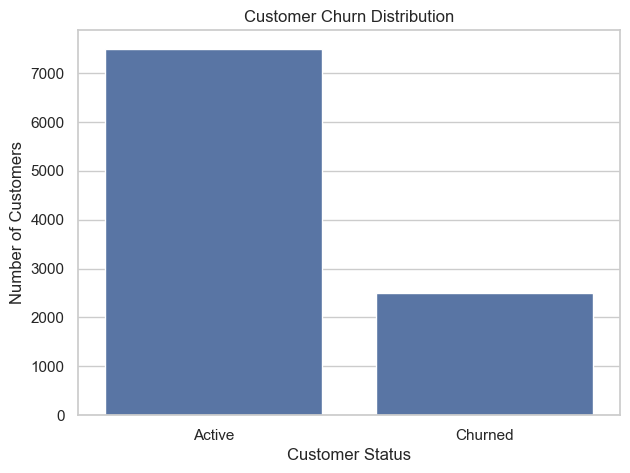

In [123]:
# ============================================
# CELL 29: CHURN DISTRIBUTION
# ============================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="churn_status"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

plt.show()

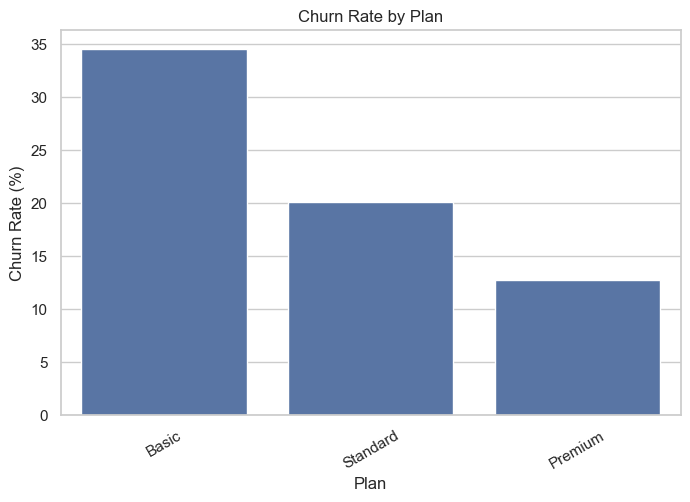

In [124]:
# ============================================
# CELL 30: CHURN BY PLAN
# ============================================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=churn_by_plan,
    x="plan_type",
    y="Churn_Rate"
)

plt.title("Churn Rate by Plan")
plt.xlabel("Plan")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=30)

plt.show()

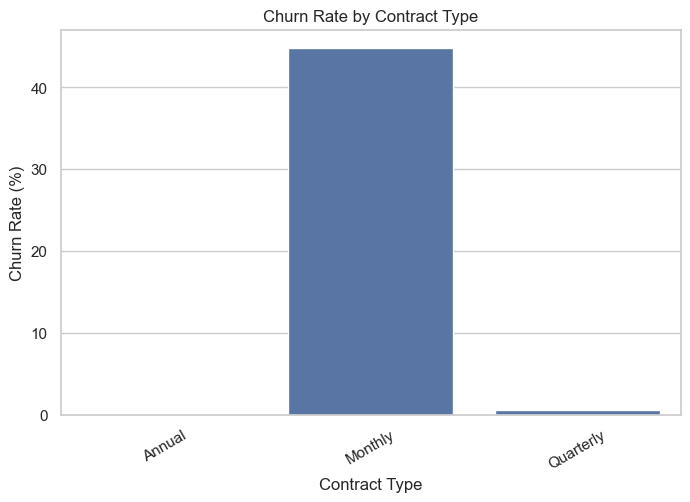

In [125]:
# ============================================
# CELL 31: CONTRACT CHURN
# ============================================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=churn_by_contract,
    x="contract_type",
    y="Churn_Rate"
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=30)

plt.show()

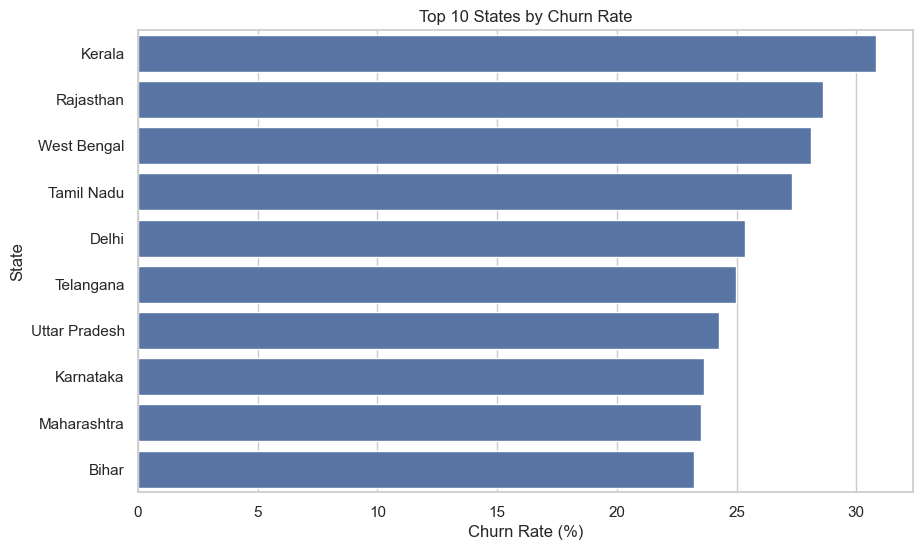

In [126]:
# ============================================
# CELL 32: STATE CHURN
# ============================================

top_states = churn_by_state.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_states,
    y="state",
    x="Churn_Rate"
)

plt.title("Top 10 States by Churn Rate")
plt.xlabel("Churn Rate (%)")
plt.ylabel("State")

plt.show()

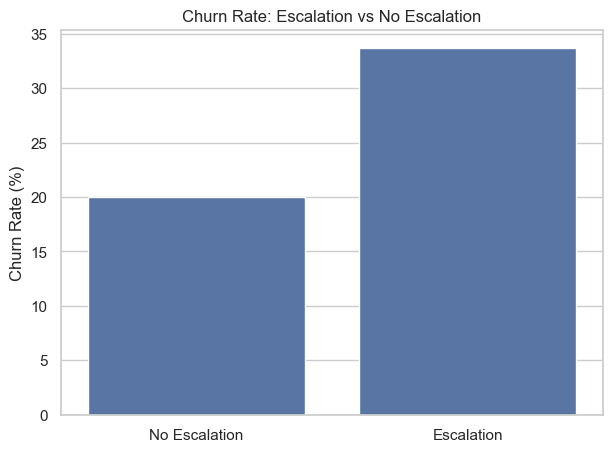

In [127]:
# ============================================
# CELL 33: ESCALATION VS CHURN
# ============================================

plt.figure(figsize=(7, 5))

sns.barplot(
    data=escalation_churn,
    x="Escalation_Status",
    y="Churn_Rate"
)

plt.title("Churn Rate: Escalation vs No Escalation")
plt.xlabel("")
plt.ylabel("Churn Rate (%)")

plt.show()

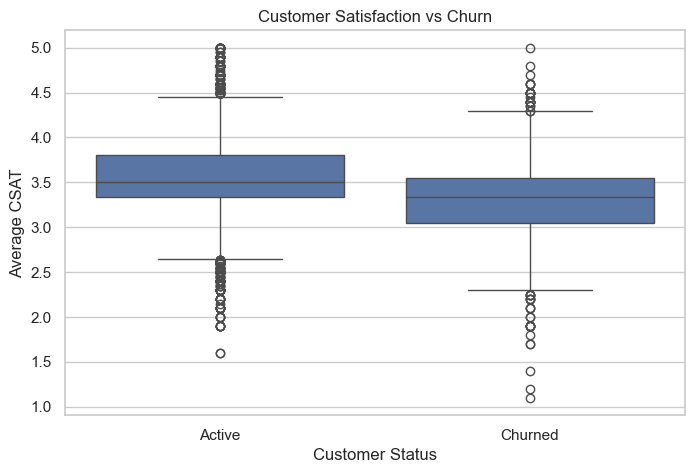

In [128]:
# ============================================
# CELL 34: CSAT VS CHURN
# ============================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="churn_status",
    y="avg_csat"
)

plt.title("Customer Satisfaction vs Churn")
plt.xlabel("Customer Status")
plt.ylabel("Average CSAT")

plt.show()

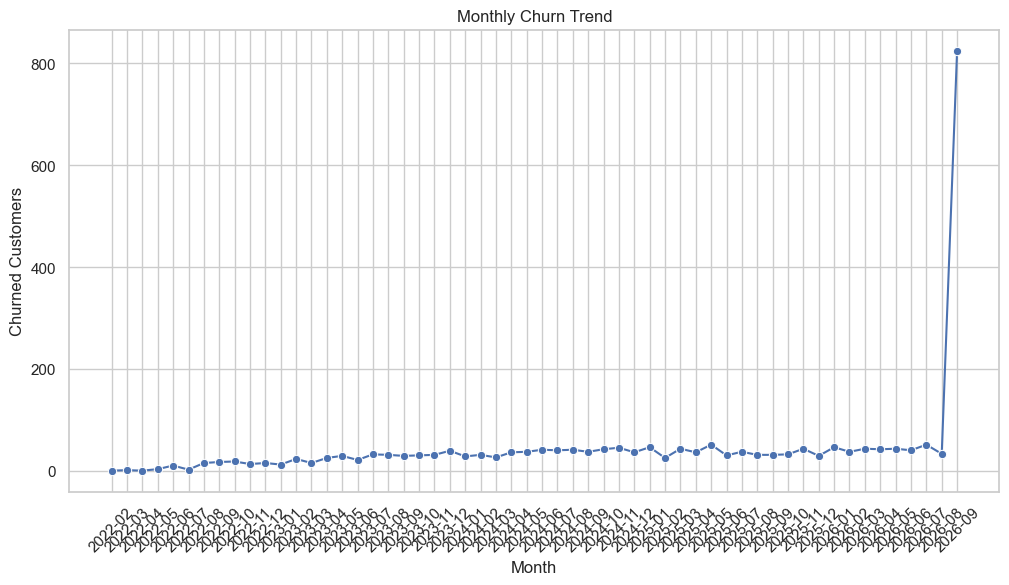

In [129]:
# ============================================
# CELL 35: MONTHLY CHURN
# ============================================

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_churn,
    x="churn_month",
    y="Churned_Customers",
    marker="o"
)

plt.title("Monthly Churn Trend")
plt.xlabel("Month")
plt.ylabel("Churned Customers")

plt.xticks(rotation=45)

plt.show()

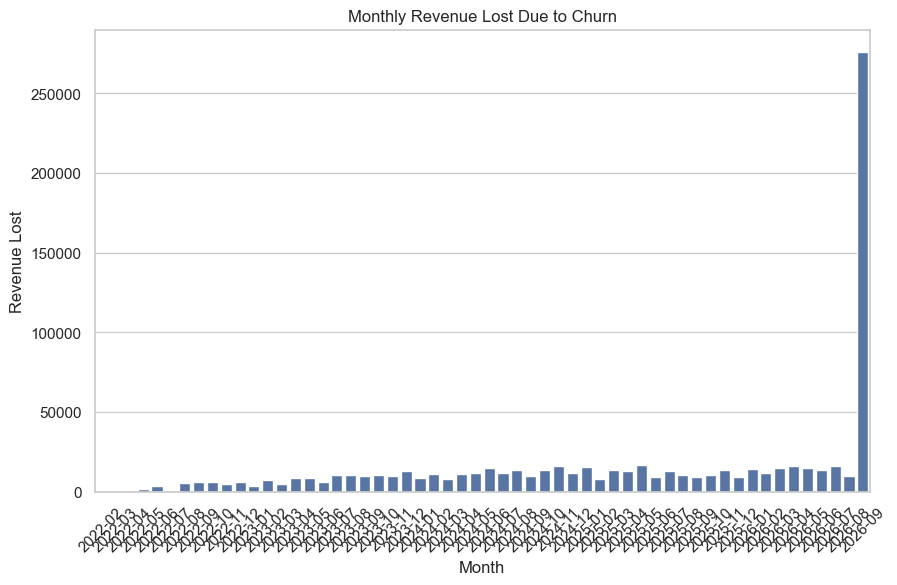

In [130]:
# ============================================
# CELL 36: REVENUE LOSS
# ============================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=monthly_churn,
    x="churn_month",
    y="Revenue_Lost"
)

plt.title("Monthly Revenue Lost Due to Churn")
plt.xlabel("Month")
plt.ylabel("Revenue Lost")

plt.xticks(rotation=45)

plt.show()

In [131]:
# ============================================
# CELL 37: HIGH RISK CUSTOMERS
# ============================================

high_risk = df[
    (df["churn_score"] >= 70) &
    (df["churn_flag"] == 0)
].copy()

print("Active high-risk customers:", len(high_risk))

print(
    "Monthly revenue at risk:",
    round(
        high_risk["monthly_charges"].sum(),
        2
    )
)

display(
    high_risk[
        [
            "customerid",
            "name",
            "state",
            "plan_type",
            "contract_type",
            "monthly_charges",
            "cltv",
            "churn_score",
            "total_complaints",
            "total_escalations",
            "avg_csat"
        ]
    ]
    .sort_values(
        "churn_score",
        ascending=False
    )
    .head(20)
)

Active high-risk customers: 368
Monthly revenue at risk: 94653.0


,customerid,name,state,plan_type,contract_type,monthly_charges,cltv,churn_score,total_complaints,total_escalations,avg_csat
7827,CUST107827,Ananya Nair,Maharashtra,Basic,Monthly,188.0,618.53,89,5.0,0.0,3.560000
5756,CUST105756,Neha Joshi,Maharashtra,Basic,Monthly,211.0,801.06,88,1.0,0.0,3.600000
6956,CUST106956,Aditya Singh,West Bengal,Basic,Monthly,190.0,476.75,88,3.0,1.0,3.400000
5183,CUST105183,Vikas Kapoor,Gujarat,Basic,Monthly,192.0,451.21,87,2.0,0.0,2.850000
1837,CUST101837,Tanvi Yadav,Delhi,Basic,Monthly,211.0,938.46,83,2.0,0.0,2.750000
8070,CUST108070,Tanvi Bose,Delhi,Basic,Monthly,196.0,342.36,82,3.0,0.0,3.766667
4611,CUST104611,Ishaan Rao,West Bengal,Basic,Monthly,354.0,1408.78,82,3.0,0.0,3.566667
2423,CUST102423,Aniket Sharma,Maharashtra,Basic,Monthly,339.0,1301.89,82,3.0,1.0,3.633333
2270,CUST102270,Sakshi Desai,Telangana,Basic,Monthly,201.0,577.25,81,2.0,2.0,2.850000
2975,CUST102975,Sonali Patel,Uttar Pradesh,Basic,Monthly,198.0,745.35,81,3.0,0.0,3.800000


In [132]:
# ============================================
# CELL 38: REVENUE AT RISK BY PLAN
# ============================================

risk_revenue_plan = (
    high_risk
    .groupby("plan_type")
    .agg(
        High_Risk_Customers=("customerid", "count"),
        Monthly_Revenue_At_Risk=("monthly_charges", "sum"),
        CLTV_At_Risk=("cltv", "sum")
    )
    .reset_index()
)

display(
    risk_revenue_plan.sort_values(
        "Monthly_Revenue_At_Risk",
        ascending=False
    )
)

,plan_type,High_Risk_Customers,Monthly_Revenue_At_Risk,CLTV_At_Risk
0,Basic,347,83572.0,275050.22
1,Premium,11,7155.0,16569.13
2,Standard,10,3926.0,11005.39


In [133]:
# ============================================
# CELL 39: RISK SEGMENTATION
# ============================================

risk_summary = (
    df[df["churn_flag"] == 0]
    .groupby("risk_category")
    .agg(
        Customers=("customerid", "count"),
        Avg_Monthly_Charges=("monthly_charges", "mean"),
        Total_Monthly_Revenue=("monthly_charges", "sum"),
        Avg_CLTV=("cltv", "mean"),
        Avg_Complaints=("total_complaints", "mean"),
        Avg_Escalations=("total_escalations", "mean"),
        Avg_CSAT=("avg_csat", "mean")
    )
    .reset_index()
)

display(risk_summary)

,risk_category,Customers,Avg_Monthly_Charges,Total_Monthly_Revenue,Avg_CLTV,Avg_Complaints,Avg_Escalations,Avg_CSAT
0,High Risk,368,257.209239,94653.0,822.349837,2.255435,0.600543,3.400096
1,Low Risk,3791,397.854656,1508267.0,1269.140472,1.537325,0.311791,3.648417
2,Medium Risk,3341,382.180186,1276864.0,1210.853948,2.048788,0.489674,3.477527


In [134]:
# ============================================
# CELL 40: CREATE SQLITE DATABASE
# ============================================

conn = sqlite3.connect("customer_churn.db")

customers.to_sql(
    "db_customer",
    conn,
    if_exists="replace",
    index=False
)

subscriptions.to_sql(
    "db_subscription",
    conn,
    if_exists="replace",
    index=False
)

support.to_sql(
    "db_support",
    conn,
    if_exists="replace",
    index=False
)

print("SQLite database created successfully.")

SQLite database created successfully.


In [135]:
# ============================================
# CELL 41: SQL CUSTOMER COUNT
# ============================================

query = """
SELECT COUNT(*) AS total_customers
FROM db_customer;
"""

sql_result = pd.read_sql_query(
    query,
    conn
)

display(sql_result)

,total_customers
0,10000


In [136]:
# ============================================
# CELL 42: SQL CHURN ANALYSIS
# ============================================

query = """
SELECT
    plan_type,
    COUNT(*) AS total_customers,
    SUM(
        CASE
            WHEN cancellation_date IS NOT NULL
            THEN 1
            ELSE 0
        END
    ) AS churned_customers,
    ROUND(
        100.0 *
        SUM(
            CASE
                WHEN cancellation_date IS NOT NULL
                THEN 1
                ELSE 0
            END
        ) / COUNT(*),
        2
    ) AS churn_rate
FROM db_subscription
GROUP BY plan_type
ORDER BY churn_rate DESC;
"""

display(
    pd.read_sql_query(query, conn)
)

,plan_type,total_customers,churned_customers,churn_rate
0,Basic,4304,1490,34.62
1,Standard,3859,776,20.11
2,Premium,1837,234,12.74


In [137]:
# ============================================
# CELL 43: SQL CONTRACT ANALYSIS
# ============================================

query = """
SELECT
    contract_type,
    COUNT(*) AS customers,
    SUM(
        CASE
            WHEN cancellation_date IS NOT NULL
            THEN 1
            ELSE 0
        END
    ) AS churned,
    ROUND(
        100.0 *
        SUM(
            CASE
                WHEN cancellation_date IS NOT NULL
                THEN 1
                ELSE 0
            END
        ) / COUNT(*),
        2
    ) AS churn_rate
FROM db_subscription
GROUP BY contract_type
ORDER BY churn_rate DESC;
"""

display(
    pd.read_sql_query(query, conn)
)

,contract_type,customers,churned,churn_rate
0,Monthly,5552,2488,44.81
1,Quarterly,2378,12,0.50
2,Annual,2070,0,0.00


In [138]:
# ============================================
# CELL 44: SQL STATE ANALYSIS
# ============================================

query = """
SELECT
    c.state,
    COUNT(*) AS customers,
    SUM(
        CASE
            WHEN s.cancellation_date IS NOT NULL
            THEN 1
            ELSE 0
        END
    ) AS churned,
    ROUND(
        100.0 *
        SUM(
            CASE
                WHEN s.cancellation_date IS NOT NULL
                THEN 1
                ELSE 0
            END
        ) / COUNT(*),
        2
    ) AS churn_rate
FROM db_customer c
JOIN db_subscription s
    ON c.customerid = s.customerid
GROUP BY c.state
ORDER BY churn_rate DESC;
"""

display(
    pd.read_sql_query(query, conn)
)

,state,customers,churned,churn_rate
0,Kerala,305,94,30.82
1,Rajasthan,678,194,28.61
2,West Bengal,985,277,28.12
3,Tamil Nadu,897,245,27.31
4,Delhi,904,229,25.33
5,Telangana,809,202,24.97
6,Uttar Pradesh,696,169,24.28
7,Karnataka,1232,291,23.62
8,Maharashtra,1617,380,23.50
9,Bihar,581,135,23.24


In [139]:
# ============================================
# CELL 45: SUPPORT ESCALATION ANALYSIS
# ============================================

query = """
SELECT
    CASE
        WHEN COALESCE(Escalations, 0) > 0
        THEN 'Escalation'
        ELSE 'No Escalation'
    END AS escalation_status,

    COUNT(DISTINCT customerid) AS customers,

    ROUND(
        AVG(CAST(csat_score AS REAL)),
        2
    ) AS avg_csat

FROM db_support

GROUP BY
    CASE
        WHEN COALESCE(Escalations, 0) > 0
        THEN 'Escalation'
        ELSE 'No Escalation'
    END;
"""

support_escalation_analysis = pd.read_sql_query(
    query,
    conn
)

display(support_escalation_analysis)

,escalation_status,customers,avg_csat
0,Escalation,3673,3.05
1,No Escalation,7716,3.61


In [140]:
# ============================================
# CHECK ESCALATION DATA
# ============================================

check_query = """
SELECT
    Escalations,
    COUNT(*) AS records
FROM db_support
GROUP BY Escalations
ORDER BY Escalations;
"""

display(
    pd.read_sql_query(check_query, conn)
)

,escalations,records
0,0,14885
1,1,4699


In [164]:
# ============================================
# NEW CELL 46: LEAKAGE-FREE ML DATASET
# ============================================

ml_df = df.copy()

# Target
y = ml_df["churn_flag"].copy()

# Remove columns that would cause target leakage
leakage_columns = [
    "customerid",
    "name",

    # Direct outcome information
    "churn_flag",
    "churn_status",
    "cancellation_date",
    "cancellation_reason",

    # Existing risk score created before modeling
    "churn_score",
    "risk_category",

    # Features calculated using cancellation/churn outcome
    "tenure_end_date",
    "tenure_days",
    "tenure_months",
    "tenure_years",

    # Directly calculated from churn_flag
    "revenue_lost",
    "cltv_lost",

    # Not useful for this model
    "dob",
    "subscription_start_date",
    "renewal_date",
    "comment"
]

X = ml_df.drop(
    columns=leakage_columns,
    errors="ignore"
)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print(
    (y.value_counts(normalize=True) * 100).round(2)
)

X shape: (10000, 18)
y shape: (10000,)

Target distribution:
churn_flag
0    7500
1    2500
Name: count, dtype: int64

Target percentage:
churn_flag
0    75.0
1    25.0
Name: proportion, dtype: float64


In [165]:
# ============================================
# NEW CELL 47: REMOVE IDENTIFIER-LIKE FEATURES
# ============================================

X = X.drop(
    columns=["pincode"],
    errors="ignore"
)

print("Final ML features:")
print(X.columns.tolist())

print("\nNumber of features:", X.shape[1])

Final ML features:
['country', 'state', 'gender', 'interests', 'subscription_type', 'plan_type', 'contract_type', 'monthly_charges', 'cltv', 'total_complaints', 'total_escalations', 'avg_csat', 'age', 'annual_revenue', 'escalation_flag', 'complaint_flag', 'tenure_segment']

Number of features: 17


In [166]:
# ============================================
# NEW CELL 48: FEATURE TYPES
# ============================================

numeric_features = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['monthly_charges', 'cltv', 'total_complaints', 'total_escalations', 'avg_csat', 'age', 'annual_revenue', 'escalation_flag', 'complaint_flag']

Categorical features:
['country', 'state', 'gender', 'interests', 'subscription_type', 'plan_type', 'contract_type', 'tenure_segment']


In [167]:
# ============================================
# NEW CELL 49: TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training: (8000, 17)
Testing : (2000, 17)

Training target distribution:
churn_flag
0    0.75
1    0.25
Name: proportion, dtype: float64

Testing target distribution:
churn_flag
0    0.75
1    0.25
Name: proportion, dtype: float64


In [168]:
# ============================================
# NEW CELL 50: PREPROCESSING
# ============================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [169]:
# ============================================
# NEW CELL 51: LOGISTIC REGRESSION
# ============================================

logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

logistic_model.fit(
    X_train,
    y_train
)

y_pred_logistic = logistic_model.predict(X_test)

y_prob_logistic = (
    logistic_model
    .predict_proba(X_test)[:, 1]
)

print("Logistic Regression trained.")

Logistic Regression trained.


In [170]:
# ============================================
# NEW CELL 52: LOGISTIC EVALUATION
# ============================================

log_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

log_precision = precision_score(
    y_test,
    y_pred_logistic
)

log_recall = recall_score(
    y_test,
    y_pred_logistic
)

log_f1 = f1_score(
    y_test,
    y_pred_logistic
)

log_auc = roc_auc_score(
    y_test,
    y_prob_logistic
)

print("LOGISTIC REGRESSION")
print("=" * 40)

print(f"Accuracy : {log_accuracy:.4f}")
print(f"Precision: {log_precision:.4f}")
print(f"Recall   : {log_recall:.4f}")
print(f"F1 Score : {log_f1:.4f}")
print(f"ROC AUC  : {log_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_logistic
    )
)

LOGISTIC REGRESSION
Accuracy : 0.9605
Precision: 0.8793
Recall   : 0.9760
F1 Score : 0.9251
ROC AUC  : 0.9943

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.97      1500
           1       0.88      0.98      0.93       500

    accuracy                           0.96      2000
   macro avg       0.94      0.97      0.95      2000
weighted avg       0.96      0.96      0.96      2000



In [171]:
# ============================================
# NEW CELL 53: RANDOM FOREST
# ============================================

rf_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=10,
                min_samples_split=10,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

rf_model.fit(
    X_train,
    y_train
)

y_pred_rf = rf_model.predict(X_test)

y_prob_rf = (
    rf_model
    .predict_proba(X_test)[:, 1]
)

print("Random Forest trained.")

Random Forest trained.


In [172]:
# ============================================
# NEW CELL 54: RANDOM FOREST EVALUATION
# ============================================

rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_precision = precision_score(
    y_test,
    y_pred_rf
)

rf_recall = recall_score(
    y_test,
    y_pred_rf
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf
)

rf_auc = roc_auc_score(
    y_test,
    y_prob_rf
)

print("RANDOM FOREST")
print("=" * 40)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC AUC  : {rf_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

RANDOM FOREST
Accuracy : 0.9525
Precision: 0.8559
Recall   : 0.9740
F1 Score : 0.9111
ROC AUC  : 0.9928

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1500
           1       0.86      0.97      0.91       500

    accuracy                           0.95      2000
   macro avg       0.92      0.96      0.94      2000
weighted avg       0.96      0.95      0.95      2000



In [173]:
# ============================================
# NEW CELL 55: MODEL COMPARISON
# ============================================

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy": [
        log_accuracy,
        rf_accuracy
    ],

    "Precision": [
        log_precision,
        rf_precision
    ],

    "Recall": [
        log_recall,
        rf_recall
    ],

    "F1 Score": [
        log_f1,
        rf_f1
    ],

    "ROC AUC": [
        log_auc,
        rf_auc
    ]
})

display(
    model_comparison
    .sort_values(
        "ROC AUC",
        ascending=False
    )
    .round(4)
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.9605,0.8793,0.976,0.9251,0.9943
1,Random Forest,0.9525,0.8559,0.974,0.9111,0.9928


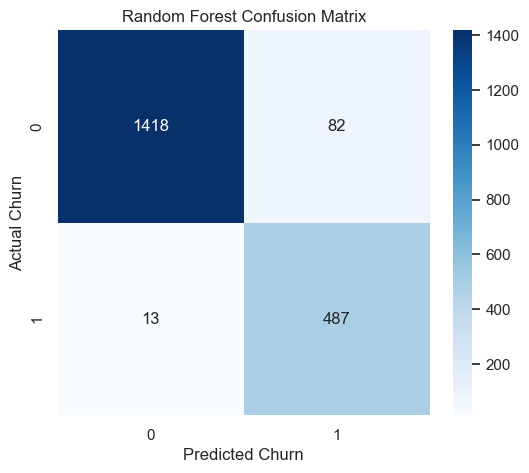

In [174]:
# ============================================
# NEW CELL 56: RANDOM FOREST CONFUSION MATRIX
# ============================================

cm = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Churn")
plt.ylabel("Actual Churn")

plt.show()

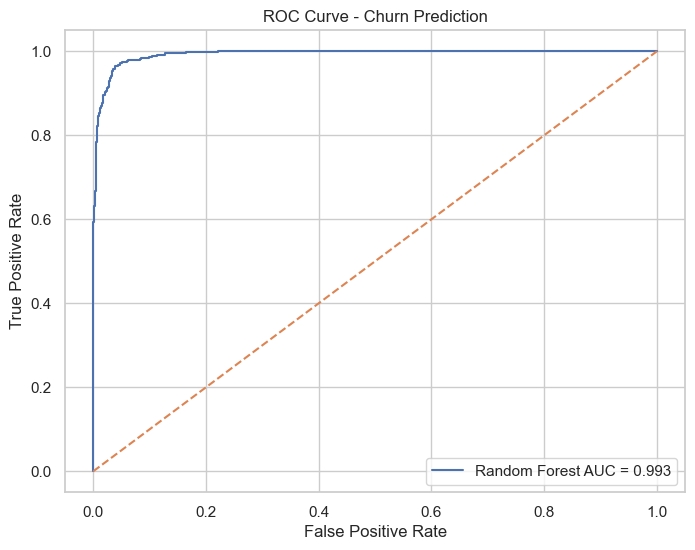

In [175]:
# ============================================
# NEW CELL 57: ROC CURVE
# ============================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest AUC = {rf_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Churn Prediction")

plt.legend()

plt.show()

In [176]:
# ============================================
# NEW CELL 58: FEATURE IMPORTANCE
# ============================================

rf_classifier = (
    rf_model
    .named_steps["classifier"]
)

rf_preprocessor = (
    rf_model
    .named_steps["preprocessor"]
)

feature_names = (
    rf_preprocessor
    .get_feature_names_out()
)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_classifier.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
)

display(
    importance_df.head(20)
)

,Feature,Importance
48,categorical__tenure_segment_3+ Years,0.231181
43,categorical__contract_type_Monthly,0.201072
1,numeric__cltv,0.103821
45,categorical__tenure_segment_0-6 Months,0.082201
49,categorical__tenure_segment_6-12 Months,0.077824
44,categorical__contract_type_Quarterly,0.059655
42,categorical__contract_type_Annual,0.055827
47,categorical__tenure_segment_2-3 Years,0.047641
46,categorical__tenure_segment_1-2 Years,0.026916
4,numeric__avg_csat,0.019334


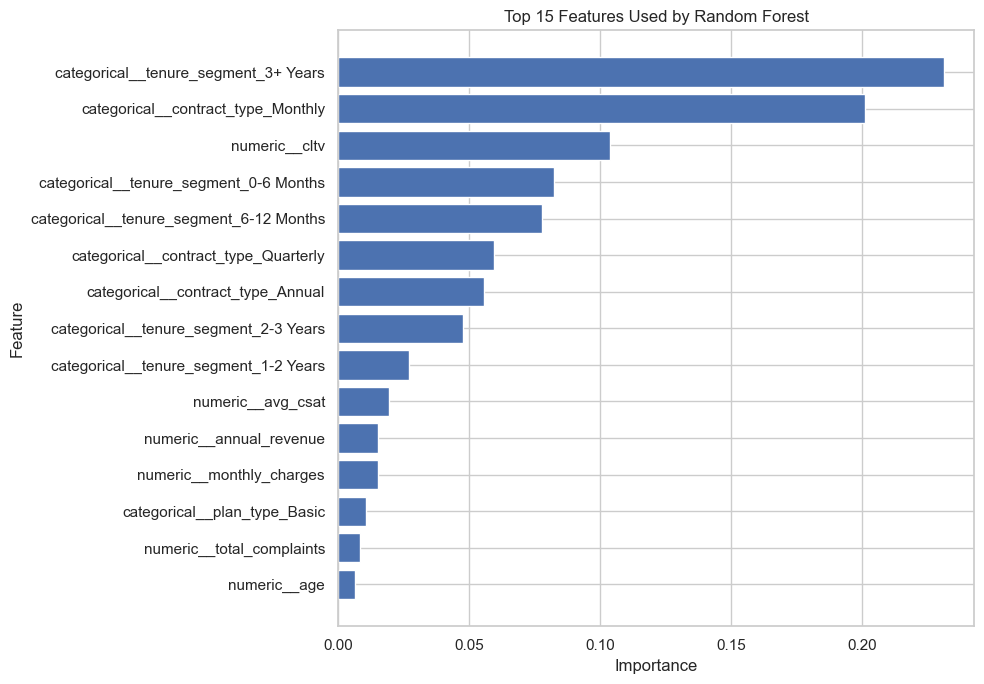

In [177]:
# ============================================
# NEW CELL 59: FEATURE IMPORTANCE PLOT
# ============================================

top_features = (
    importance_df
    .head(15)
    .sort_values("Importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title(
    "Top 15 Features Used by Random Forest"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [178]:
# ============================================
# NEW CELL 60: CUSTOMER CHURN PROBABILITY
# ============================================

X_all = X.copy()

df_predictions = df.copy()

df_predictions["predicted_churn_probability"] = (
    rf_model
    .predict_proba(X_all)[:, 1]
)

df_predictions["predicted_churn_probability"] *= 100

df_predictions["predicted_risk"] = pd.cut(
    df_predictions[
        "predicted_churn_probability"
    ],

    bins=[
        -1,
        30,
        60,
        100
    ],

    labels=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]
)

display(
    df_predictions[
        [
            "customerid",
            "name",
            "plan_type",
            "contract_type",
            "monthly_charges",
            "predicted_churn_probability",
            "predicted_risk"
        ]
    ]
    .sort_values(
        "predicted_churn_probability",
        ascending=False
    )
    .head(20)
)

,customerid,name,plan_type,contract_type,monthly_charges,predicted_churn_probability,predicted_risk
5921,CUST105921,Khushi Iyer,Basic,Monthly,209.0,99.094646,High Risk
9318,CUST109318,Sakshi Kapoor,Basic,Monthly,309.0,99.058015,High Risk
3393,CUST103393,Sneha Gupta,Basic,Monthly,189.0,99.046676,High Risk
8752,CUST108752,Ishaan Yadav,Basic,Monthly,191.0,99.040864,High Risk
9733,CUST109733,Meera Tiwari,Basic,Monthly,200.0,99.019753,High Risk
4287,CUST104287,Ishaan Gupta,Basic,Monthly,191.0,98.992048,High Risk
9590,CUST109590,Ishaan Verma,Basic,Monthly,221.0,98.980890,High Risk
2883,CUST102883,Meera Kulkarni,Basic,Monthly,297.0,98.979433,High Risk
8167,CUST108167,Zoya Bose,Basic,Monthly,302.0,98.978505,High Risk
2346,CUST102346,Vikram Singh,Basic,Monthly,294.0,98.965647,High Risk


In [179]:
# ============================================
# NEW CELL 61: ACTIVE CUSTOMERS AT RISK
# ============================================

active_high_risk = (
    df_predictions[
        (df_predictions["churn_flag"] == 0) &
        (df_predictions["predicted_risk"] == "High Risk")
    ]
    .copy()
)

print(
    "Active high-risk customers:",
    len(active_high_risk)
)

print(
    "Monthly revenue exposed:",
    round(
        active_high_risk["monthly_charges"].sum(),
        2
    )
)

print(
    "CLTV exposed:",
    round(
        active_high_risk["cltv"].sum(),
        2
    )
)

display(
    active_high_risk[
        [
            "customerid",
            "name",
            "state",
            "plan_type",
            "contract_type",
            "monthly_charges",
            "cltv",
            "total_complaints",
            "total_escalations",
            "avg_csat",
            "predicted_churn_probability"
        ]
    ]
    .sort_values(
        "predicted_churn_probability",
        ascending=False
    )
    .head(50)
)

Active high-risk customers: 229
Monthly revenue exposed: 74427.0
CLTV exposed: 153563.67


,customerid,name,state,plan_type,contract_type,monthly_charges,cltv,total_complaints,total_escalations,avg_csat,predicted_churn_probability
9069,CUST109069,Sonali Dutta,West Bengal,Basic,Monthly,200.0,406.27,4.0,3.0,2.725000,92.485518
9042,CUST109042,Neha Bose,West Bengal,Basic,Monthly,187.0,406.75,4.0,0.0,3.275000,91.887188
9093,CUST109093,Mohit Bose,Karnataka,Basic,Monthly,201.0,458.79,4.0,3.0,2.500000,91.610953
1863,CUST101863,Tanvi Jain,Tamil Nadu,Basic,Monthly,185.0,445.83,3.0,1.0,3.066667,91.511279
4641,CUST104641,Aniket Bose,Maharashtra,Basic,Monthly,199.0,487.29,1.0,0.0,2.900000,91.496503
4534,CUST104534,Vikas Yadav,Tamil Nadu,Basic,Monthly,206.0,452.18,3.0,3.0,3.166667,91.352641
8484,CUST108484,Zoya Pillai,Rajasthan,Basic,Monthly,203.0,467.87,1.0,1.0,3.400000,91.286434
5470,CUST105470,Pranav Das,Telangana,Basic,Monthly,197.0,451.06,2.0,0.0,3.000000,90.884983
8951,CUST108951,Aryan Mishra,Tamil Nadu,Basic,Monthly,224.0,504.75,3.0,0.0,3.100000,90.882825
651,CUST100651,Isha Nair,Bihar,Basic,Monthly,205.0,432.31,2.0,0.0,3.350000,90.237270


In [180]:
# ============================================
# NEW CELL 62: CUSTOMER SEGMENT ANALYSIS
# ============================================

df["charge_segment"] = pd.qcut(
    df["monthly_charges"],
    q=4,
    labels=[
        "Low",
        "Medium-Low",
        "Medium-High",
        "High"
    ]
)

charge_churn = (
    df.groupby(
        "charge_segment",
        observed=True
    )
    .agg(
        Customers=("customerid", "count"),
        Churned=("churn_flag", "sum"),
        Churn_Rate=("churn_flag", "mean"),
        Avg_Charges=("monthly_charges", "mean"),
        Avg_CLTV=("cltv", "mean")
    )
    .reset_index()
)

charge_churn["Churn_Rate"] *= 100

display(charge_churn)

,charge_segment,Customers,Churned,Churn_Rate,Avg_Charges,Avg_CLTV
0,Low,2501,854,34.146341,194.641743,549.833119
1,Medium-Low,2513,717,28.531635,302.771190,876.019813
2,Medium-High,2496,530,21.233974,381.112179,1127.561430
3,High,2490,399,16.024096,598.369076,1790.102566


In [181]:
# ============================================
# NEW CELL 63: CANCELLATION REASON IMPACT
# ============================================

cancellation_impact = (
    df[df["churn_flag"] == 1]
    .groupby("cancellation_reason")
    .agg(
        Churned_Customers=("customerid", "count"),
        Revenue_Lost=("monthly_charges", "sum"),
        CLTV_Lost=("cltv", "sum")
    )
    .reset_index()
)

cancellation_impact["Share_of_Churn"] = (
    cancellation_impact["Churned_Customers"]
    /
    cancellation_impact["Churned_Customers"].sum()
    * 100
)

cancellation_impact = (
    cancellation_impact
    .sort_values(
        "Revenue_Lost",
        ascending=False
    )
)

display(cancellation_impact)

,cancellation_reason,Churned_Customers,Revenue_Lost,CLTV_Lost,Share_of_Churn
5,Price too high,624,199782.0,421913.25,24.96
1,Content dissatisfaction,398,133452.0,276265.34,15.92
2,Not using service,343,113044.0,233353.61,13.72
0,Competitor switch,324,103079.0,215324.34,12.96
6,Technical issues,263,85793.0,180341.15,10.52
4,Poor customer support,229,73311.0,154348.48,9.16
7,Temporary pause,157,50944.0,106202.11,6.28
3,Payment issues,162,49669.0,101171.55,6.48


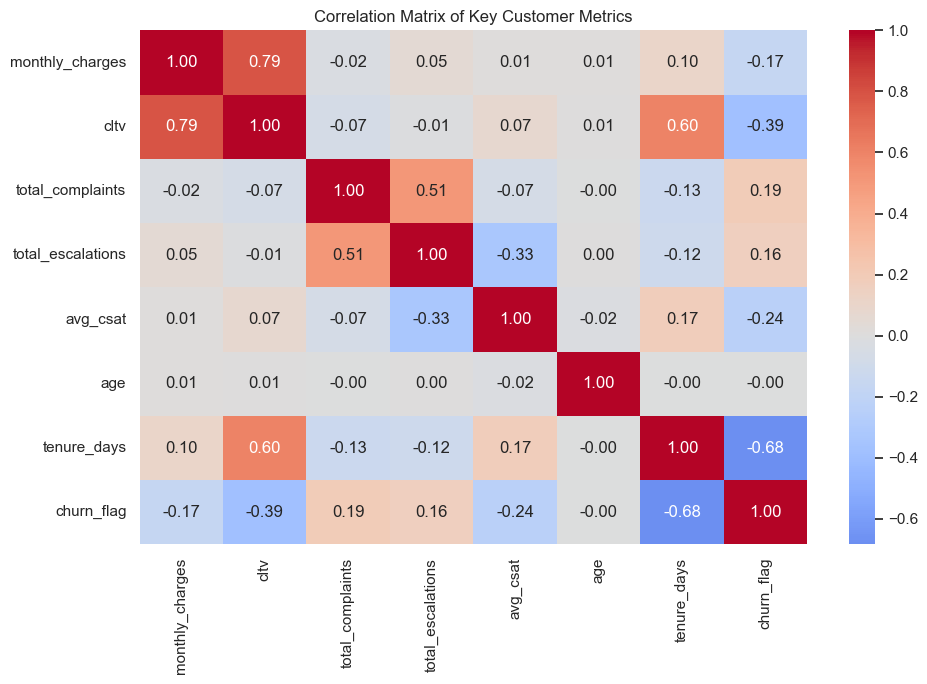

In [182]:
# ============================================
# NEW CELL 64: NUMERIC FEATURE CORRELATION
# ============================================

numeric_analysis = df[
    [
        "monthly_charges",
        "cltv",
        "total_complaints",
        "total_escalations",
        "avg_csat",
        "age",
        "tenure_days",
        "churn_flag"
    ]
].copy()

correlation_matrix = (
    numeric_analysis.corr()
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Matrix of Key Customer Metrics"
)

plt.tight_layout()
plt.show()

In [183]:
# ============================================
# NEW CELL 65: EXECUTIVE KPI TABLE
# ============================================

executive_kpis = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Active Customers",
        "Churned Customers",
        "Churn Rate",
        "Retention Rate",
        "Average Tenure",
        "ARPU",
        "Revenue Lost",
        "CLTV Lost",
        "Average Complaints"
    ],

    "Value": [
        f"{total_customers:,}",
        f"{active_customers:,}",
        f"{churned_customers:,}",
        f"{churn_rate:.2f}%",
        f"{retention_rate:.2f}%",
        f"{avg_tenure:.0f} days",
        f"{arpu:.2f}",
        f"{revenue_loss:,.2f}",
        f"{cltv_lost:,.2f}",
        f"{avg_complaints:.2f}"
    ]
})

display(executive_kpis)

,Metric,Value
0,Total Customers,"10,000"
1,Active Customers,"7,500"
2,Churned Customers,"2,500"
3,Churn Rate,25.00%
4,Retention Rate,75.00%
5,Average Tenure,1007 days
6,ARPU,383.97
7,Revenue Lost,"809,074.00"
8,CLTV Lost,"1,688,919.83"
9,Average Complaints,1.96


In [161]:
# ============================================
# CELL 66: EXPORT HIGH-RISK CUSTOMERS
# ============================================

high_risk_customers.to_csv(
    "high_risk_customers.csv",
    index=False
)

print(
    "High-risk customer report saved."
)

High-risk customer report saved.


In [162]:
# ============================================
# CELL 67: CLOSE DATABASE
# ============================================

conn.close()

print("Database connection closed.")

Database connection closed.


In [163]:
# ============================================
# CELL 68: PROJECT SUMMARY
# ============================================

print("=" * 60)
print("CUSTOMER CHURN & RETENTION ANALYTICS")
print("=" * 60)

print(f"Total Customers       : {total_customers:,}")
print(f"Active Customers      : {active_customers:,}")
print(f"Churned Customers     : {churned_customers:,}")
print(f"Churn Rate            : {churn_rate:.2f}%")
print(f"Retention Rate        : {retention_rate:.2f}%")
print(f"Average Tenure        : {avg_tenure:.2f} days")
print(f"ARPU                  : {arpu:.2f}")
print(f"Revenue Lost          : {revenue_loss:.2f}")
print(f"CLTV Lost             : {cltv_lost:.2f}")
print(f"Revenue At Risk       : {revenue_at_risk:.2f}")
print(f"Escalation Rate       : {escalation_rate:.2f}%")
print(f"Average Complaints    : {avg_complaints:.2f}")

print("=" * 60)
print("PROJECT COMPLETED")
print("=" * 60)

CUSTOMER CHURN & RETENTION ANALYTICS
Total Customers       : 10,000
Active Customers      : 7,500
Churned Customers     : 2,500
Churn Rate            : 25.00%
Retention Rate        : 75.00%
Average Tenure        : 1006.62 days
ARPU                  : 383.97
Revenue Lost          : 809074.00
CLTV Lost             : 1688919.83
Revenue At Risk       : 75899.00
Escalation Rate       : 36.73%
Average Complaints    : 1.96
PROJECT COMPLETED
